# Blood Cell Cancer (ALL) – RL-based CNN Models
We train **6 CNN classifiers** on the 4-class ALL PBS dataset and then
wrap each CNN with a **reinforcement learning (RL) policy** that learns
which data augmentation to apply (an augmentation bandit).

This gives 6 *RL-based CNN models* (CNN + learned RL augmentation policy).

Hardware assumptions:

- **GPU:** NVIDIA A100 80GB
- **CPU:** Intel Xeon, 42 cores
- **RAM:** 64 GB

Hyperparameters (as requested):

- `BATCH_SIZE = 256`
- `NUM_WORKERS = 36`
- `NUM_EPOCHS = 150`


In [7]:
# =========================
# Imports & global settings
# =========================

import os
import random
from pathlib import Path
from typing import List, Dict

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Hyperparameters (as requested)
BATCH_SIZE = 256
IMG_SIZE = 224
NUM_WORKERS = 36
NUM_EPOCHS = 150
LEARNING_RATE = 1e-4

DATA_ROOT = Path("./data")
KAGGLE_DATASET_NAME = "mohammadamireshraghi/blood-cell-cancer-all-4class"

# Create output dirs
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("figures", exist_ok=True)
os.makedirs("rl_policies", exist_ok=True)

Using device: cuda


## Download dataset from Kaggle
Requires Kaggle CLI configured with `kaggle.json`.

If you're on Kaggle Notebooks, you can skip the download and instead
set `DATASET_DIR` to `/kaggle/input/...` path for this dataset.

In [8]:
def download_dataset():
    """Download Blood Cell Cancer (ALL) 4-class dataset via Kaggle CLI."""
    target_dir = DATA_ROOT / "blood-cell-cancer-all-4class"
    if target_dir.exists():
        print("Dataset already exists at", target_dir)
        return target_dir

    os.makedirs(DATA_ROOT, exist_ok=True)
    print("Downloading dataset from Kaggle...")
    # Make sure you have: pip install kaggle && kaggle.json configured
    os.system(f"kaggle datasets download -d {KAGGLE_DATASET_NAME} -p {DATA_ROOT} --unzip")

    # Try to auto-detect the extracted folder
    for p in DATA_ROOT.iterdir():
        if p.is_dir() and "Blood" in p.name and "Cancer" in p.name:
            p.rename(target_dir)
            break

    if not target_dir.exists():
        raise RuntimeError("Could not locate extracted dataset folder. Check the folder structure.")

    print("Download & extraction complete. Folder:", target_dir)
    return target_dir

DATASET_DIR = download_dataset()

# Adjust if needed depending on the folder structure after unzip
image_root = DATASET_DIR
print("Image root:", image_root)

Dataset URL: https://www.kaggle.com/datasets/mohammadamireshraghi/blood-cell-cancer-all-4class
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)


100%|██████████| 1.68G/1.68G [00:01<00:00, 1.03GB/s]



Download & extraction complete. Folder: data/blood-cell-cancer-all-4class
Image root: data/blood-cell-cancer-all-4class


## Dataset, transforms, and stratified train/val/test split

In [9]:
# Data augmentation and normalization
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

full_dataset = datasets.ImageFolder(root=str(image_root), transform=train_transform)
class_names = full_dataset.classes
num_classes = len(class_names)
print("Classes:", class_names)
print("Total images:", len(full_dataset))


def stratified_split(dataset, train_size=0.7, val_size=0.15, test_size=0.15, seed=SEED):
    assert abs(train_size + val_size + test_size - 1.0) < 1e-6

    targets = np.array(dataset.targets)
    indices = np.arange(len(targets))

    # train vs temp
    sss1 = StratifiedShuffleSplit(n_splits=1, train_size=train_size, random_state=seed)
    train_idx, temp_idx = next(sss1.split(indices, targets))

    temp_targets = targets[temp_idx]
    val_ratio = val_size / (val_size + test_size)
    sss2 = StratifiedShuffleSplit(n_splits=1, train_size=val_ratio, random_state=seed)
    val_idx, test_idx = next(sss2.split(temp_idx, temp_targets))

    train_idx = indices[train_idx]
    val_idx = temp_idx[val_idx]
    test_idx = temp_idx[test_idx]

    return train_idx, val_idx, test_idx


train_idx, val_idx, test_idx = stratified_split(full_dataset)

# For train we use augmented full_dataset, for val/test we create a fresh dataset with deterministic transforms
train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(datasets.ImageFolder(root=str(image_root), transform=val_test_transform), val_idx)
test_dataset = Subset(datasets.ImageFolder(root=str(image_root), transform=val_test_transform), test_idx)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

Classes: ['Benign', '[Malignant] Pre-B', '[Malignant] Pro-B', '[Malignant] early Pre-B']
Total images: 3242
Train: 2269, Val: 486, Test: 487


## CNN backbones (ResNet/DenseNet/EfficientNet/etc.)

In [10]:
def create_model(model_name: str, num_classes: int):
    model_name = model_name.lower()
    if model_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    elif model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    elif model_name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)
    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
    elif model_name == "mobilenet_v2":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
    elif model_name == "convnext_tiny":
        model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")
    return model


MODEL_NAMES = [
    "resnet18",
    "resnet50",
    "densenet121",
    "efficientnet_b0",
    "mobilenet_v2",
    "convnext_tiny",
]

## Supervised training utilities (for CNN backbones)

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=True):
            outputs = model(inputs)
            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=False):
            outputs = model(inputs)
            loss = criterion(outputs, targets)

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def train_model(model_name: str,
                train_loader,
                val_loader,
                num_epochs: int = NUM_EPOCHS,
                lr: float = LEARNING_RATE):
    print(f"\n===== Training CNN backbone: {model_name} =====")

    model = create_model(model_name, num_classes=num_classes)
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler(enabled=True)

    best_val_acc = 0.0
    best_model_path = f"./checkpoints/{model_name}_best.pth"

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"[{model_name}] Epoch {epoch:03d}/{num_epochs:03d} "
            f"| Train loss: {train_loss:.4f}, acc: {train_acc:.4f} "
            f"| Val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"  -> New best val acc: {best_val_acc:.4f}. Model saved to {best_model_path}")

    print(f"Finished training {model_name}. Best val acc: {best_val_acc:.4f}")
    model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    return model, history


@torch.no_grad()
def test_model(model, test_loader, class_names):
    model.eval()
    all_targets = []
    all_preds = []

    for inputs, targets in test_loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_targets.extend(targets.numpy().tolist())
        all_preds.extend(predicted.cpu().numpy().tolist())

    print("\nClassification Report:")
    print(classification_report(all_targets, all_preds, target_names=class_names))

    cm = confusion_matrix(all_targets, all_preds)
    print("Confusion Matrix:\n", cm)
    return np.array(all_targets), np.array(all_preds), cm

## Step 1: Train 6 supervised CNN backbones

These will be wrapped by RL policies in the next step.

In [12]:
trained_models: Dict[str, nn.Module] = {}
histories: Dict[str, Dict[str, List[float]]] = {}
cms: Dict[str, np.ndarray] = {}

for model_name in MODEL_NAMES:
    model, history = train_model(model_name, train_loader, val_loader)
    trained_models[model_name] = model
    histories[model_name] = history

    print(f"\nTesting best {model_name} on test set...")
    _, _, cm = test_model(model, test_loader, class_names)
    cms[model_name] = cm

print("All CNN backbones trained and evaluated.")


===== Training CNN backbone: resnet18 =====


/tmp/ipykernel_3866309/2145770856.py:67: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=True)
/tmp/ipykernel_3866309/2145770856.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):
/tmp/ipykernel_3866309/2145770856.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


[resnet18] Epoch 001/150 | Train loss: 0.6161, acc: 0.7876 | Val loss: 1.1478, acc: 0.5802
  -> New best val acc: 0.5802. Model saved to ./checkpoints/resnet18_best.pth
[resnet18] Epoch 002/150 | Train loss: 0.0895, acc: 0.9793 | Val loss: 0.1963, acc: 0.9300
  -> New best val acc: 0.9300. Model saved to ./checkpoints/resnet18_best.pth
[resnet18] Epoch 003/150 | Train loss: 0.0366, acc: 0.9885 | Val loss: 0.0688, acc: 0.9753
  -> New best val acc: 0.9753. Model saved to ./checkpoints/resnet18_best.pth
[resnet18] Epoch 004/150 | Train loss: 0.0194, acc: 0.9938 | Val loss: 0.0578, acc: 0.9774
  -> New best val acc: 0.9774. Model saved to ./checkpoints/resnet18_best.pth
[resnet18] Epoch 005/150 | Train loss: 0.0199, acc: 0.9921 | Val loss: 0.0554, acc: 0.9774
[resnet18] Epoch 006/150 | Train loss: 0.0138, acc: 0.9969 | Val loss: 0.0353, acc: 0.9897
  -> New best val acc: 0.9897. Model saved to ./checkpoints/resnet18_best.pth
[resnet18] Epoch 007/150 | Train loss: 0.0123, acc: 0.9965 | Val

100%|██████████| 97.8M/97.8M [00:04<00:00, 24.7MB/s]
/tmp/ipykernel_3866309/2145770856.py:67: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=True)
/tmp/ipykernel_3866309/2145770856.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):
/tmp/ipykernel_3866309/2145770856.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


[resnet50] Epoch 001/150 | Train loss: 1.1221, acc: 0.6620 | Val loss: 0.9469, acc: 0.6008
  -> New best val acc: 0.6008. Model saved to ./checkpoints/resnet50_best.pth
[resnet50] Epoch 002/150 | Train loss: 0.5499, acc: 0.8903 | Val loss: 0.3291, acc: 0.8971
  -> New best val acc: 0.8971. Model saved to ./checkpoints/resnet50_best.pth
[resnet50] Epoch 003/150 | Train loss: 0.1807, acc: 0.9700 | Val loss: 0.1182, acc: 0.9712
  -> New best val acc: 0.9712. Model saved to ./checkpoints/resnet50_best.pth
[resnet50] Epoch 004/150 | Train loss: 0.0574, acc: 0.9855 | Val loss: 0.0427, acc: 0.9877
  -> New best val acc: 0.9877. Model saved to ./checkpoints/resnet50_best.pth
[resnet50] Epoch 005/150 | Train loss: 0.0266, acc: 0.9925 | Val loss: 0.0272, acc: 0.9897
  -> New best val acc: 0.9897. Model saved to ./checkpoints/resnet50_best.pth
[resnet50] Epoch 006/150 | Train loss: 0.0238, acc: 0.9925 | Val loss: 0.0251, acc: 0.9918
  -> New best val acc: 0.9918. Model saved to ./checkpoints/resn

...

[efficientnet_b0] Epoch 001/150 | Train loss: 1.2185, acc: 0.5289 | Val loss: 1.2266, acc: 0.5556
  -> New best val acc: 0.5556. Model saved to ./checkpoints/efficientnet_b0_best.pth
[efficientnet_b0] Epoch 002/150 | Train loss: 0.7689, acc: 0.8907 | Val loss: 0.7002, acc: 0.9198
  -> New best val acc: 0.9198. Model saved to ./checkpoints/efficientnet_b0_best.pth
[efficientnet_b0] Epoch 003/150 | Train loss: 0.3995, acc: 0.9502 | Val loss: 0.2911, acc: 0.9444
  -> New best val acc: 0.9444. Model saved to ./checkpoints/efficientnet_b0_best.pth
[efficientnet_b0] Epoch 004/150 | Train loss: 0.2065, acc: 0.9691 | Val loss: 0.1247, acc: 0.9733
  -> New best val acc: 0.9733. Model saved to ./checkpoints/efficientnet_b0_best.pth
[efficientnet_b0] Epoch 005/150 | Train loss: 0.1034, acc: 0.9841 | Val loss: 0.0685, acc: 0.9794
  -> New best val acc: 0.9794. Model saved to ./checkpoints/efficientnet_b0_best.pth
[efficientnet_b0] Epoch 006/150 | Train loss: 0.0657, acc: 0.9855 | Val loss: 0.0419,

100%|██████████| 13.6M/13.6M [00:00<00:00, 27.3MB/s]
/tmp/ipykernel_3866309/2145770856.py:67: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=True)
/tmp/ipykernel_3866309/2145770856.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):
/tmp/ipykernel_3866309/2145770856.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


[mobilenet_v2] Epoch 001/150 | Train loss: 0.8926, acc: 0.6924 | Val loss: 0.9697, acc: 0.5432
  -> New best val acc: 0.5432. Model saved to ./checkpoints/mobilenet_v2_best.pth
[mobilenet_v2] Epoch 002/150 | Train loss: 0.2336, acc: 0.9506 | Val loss: 0.2822, acc: 0.8889
  -> New best val acc: 0.8889. Model saved to ./checkpoints/mobilenet_v2_best.pth
[mobilenet_v2] Epoch 003/150 | Train loss: 0.0786, acc: 0.9802 | Val loss: 0.1063, acc: 0.9568
  -> New best val acc: 0.9568. Model saved to ./checkpoints/mobilenet_v2_best.pth
[mobilenet_v2] Epoch 004/150 | Train loss: 0.0464, acc: 0.9868 | Val loss: 0.0501, acc: 0.9835
  -> New best val acc: 0.9835. Model saved to ./checkpoints/mobilenet_v2_best.pth
[mobilenet_v2] Epoch 005/150 | Train loss: 0.0254, acc: 0.9934 | Val loss: 0.0265, acc: 0.9938
  -> New best val acc: 0.9938. Model saved to ./checkpoints/mobilenet_v2_best.pth
[mobilenet_v2] Epoch 006/150 | Train loss: 0.0204, acc: 0.9952 | Val loss: 0.0223, acc: 0.9938
[mobilenet_v2] Epoch

100%|██████████| 109M/109M [00:04<00:00, 23.9MB/s] 
/tmp/ipykernel_3866309/2145770856.py:67: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=True)
/tmp/ipykernel_3866309/2145770856.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):
/tmp/ipykernel_3866309/2145770856.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


[convnext_tiny] Epoch 001/150 | Train loss: 0.7951, acc: 0.7179 | Val loss: 0.3304, acc: 0.8992
  -> New best val acc: 0.8992. Model saved to ./checkpoints/convnext_tiny_best.pth
[convnext_tiny] Epoch 002/150 | Train loss: 0.1960, acc: 0.9590 | Val loss: 0.0868, acc: 0.9712
  -> New best val acc: 0.9712. Model saved to ./checkpoints/convnext_tiny_best.pth
[convnext_tiny] Epoch 003/150 | Train loss: 0.0640, acc: 0.9819 | Val loss: 0.0420, acc: 0.9856
  -> New best val acc: 0.9856. Model saved to ./checkpoints/convnext_tiny_best.pth
[convnext_tiny] Epoch 004/150 | Train loss: 0.0322, acc: 0.9916 | Val loss: 0.0333, acc: 0.9856
[convnext_tiny] Epoch 005/150 | Train loss: 0.0285, acc: 0.9916 | Val loss: 0.0382, acc: 0.9835
[convnext_tiny] Epoch 006/150 | Train loss: 0.0244, acc: 0.9938 | Val loss: 0.0267, acc: 0.9897
  -> New best val acc: 0.9897. Model saved to ./checkpoints/convnext_tiny_best.pth
[convnext_tiny] Epoch 007/150 | Train loss: 0.0136, acc: 0.9965 | Val loss: 0.0143, acc: 0.9

## Visualizations – CNN training & validation curves

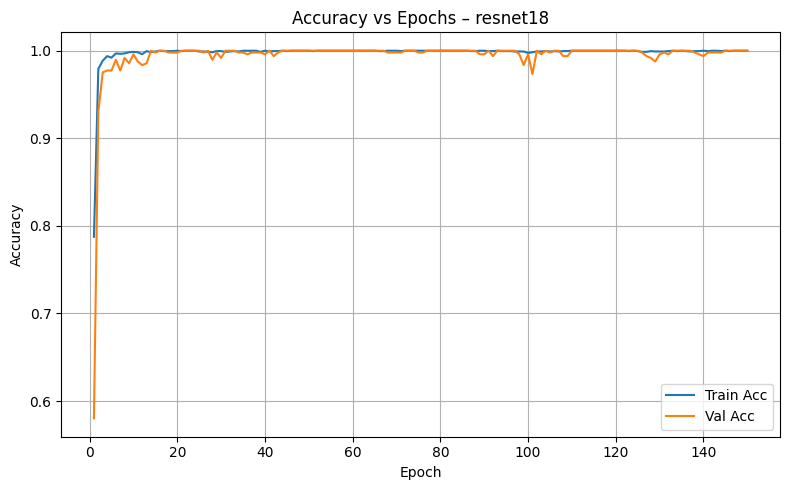

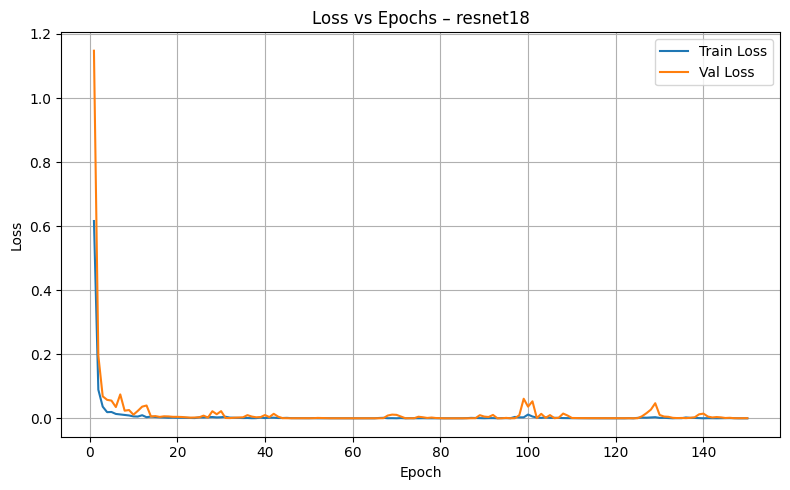

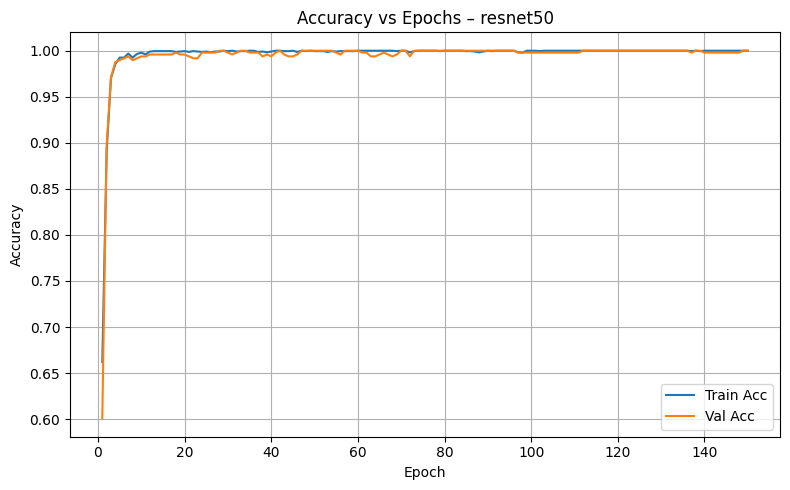

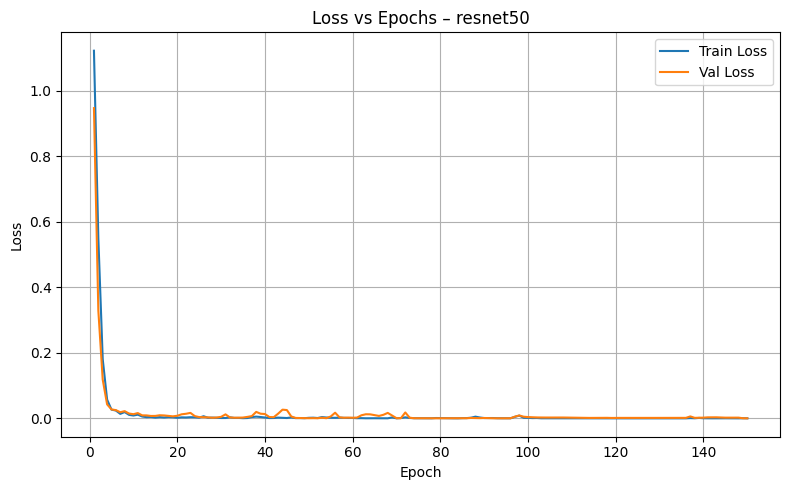

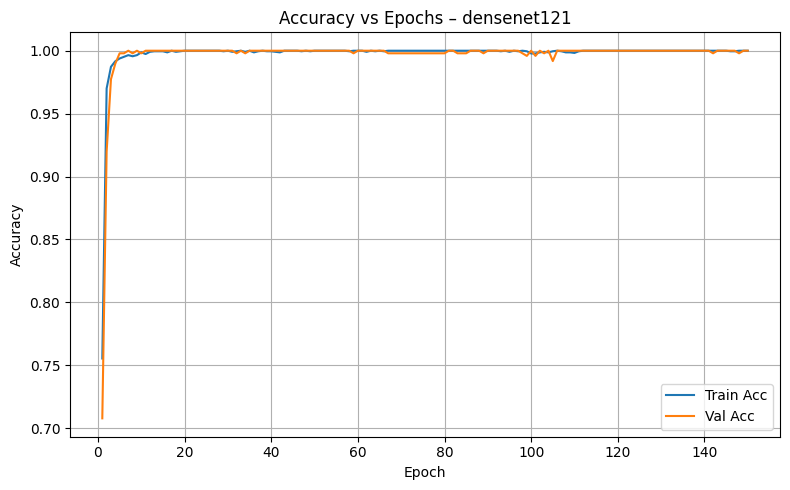

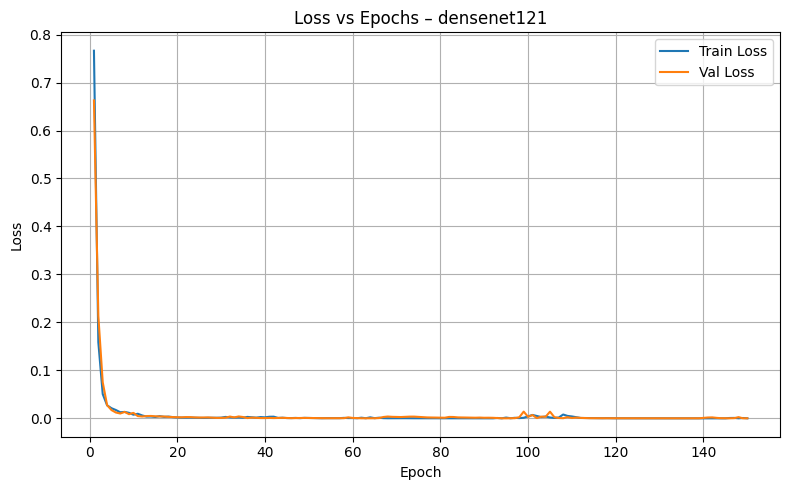

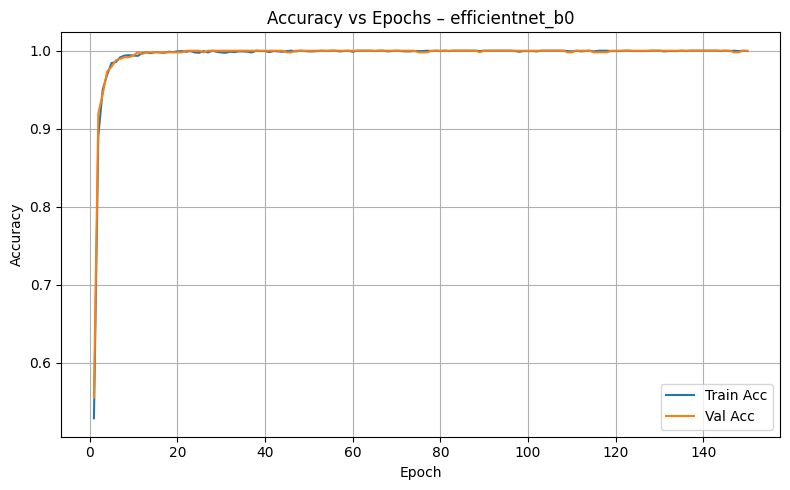

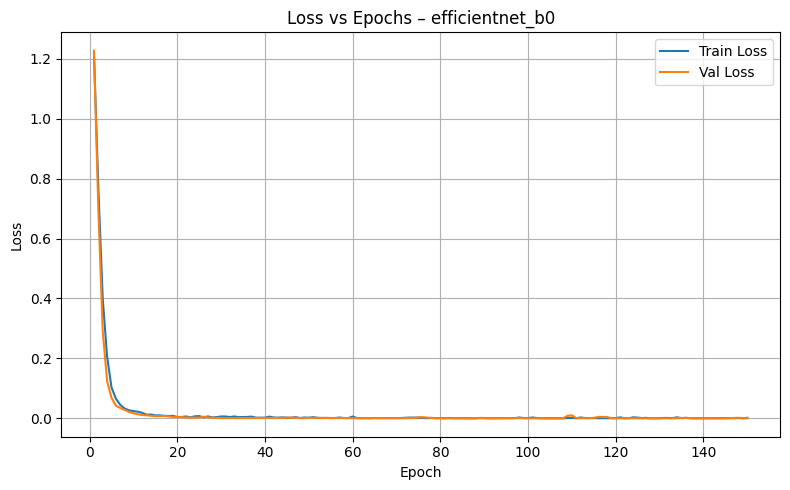

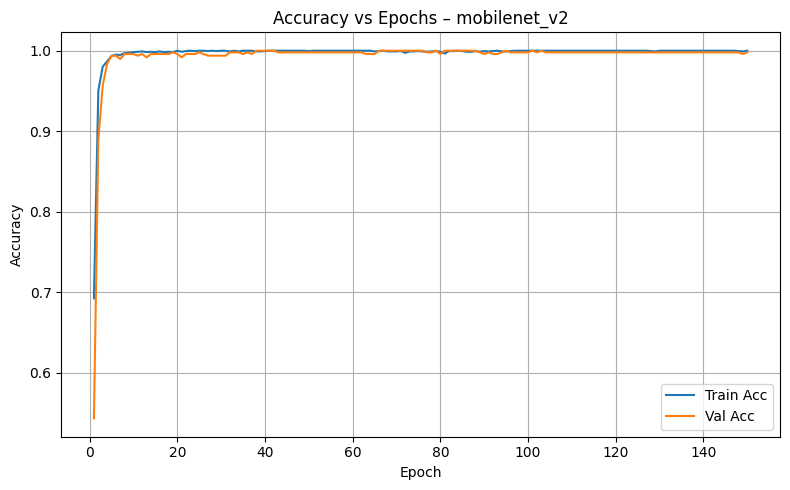

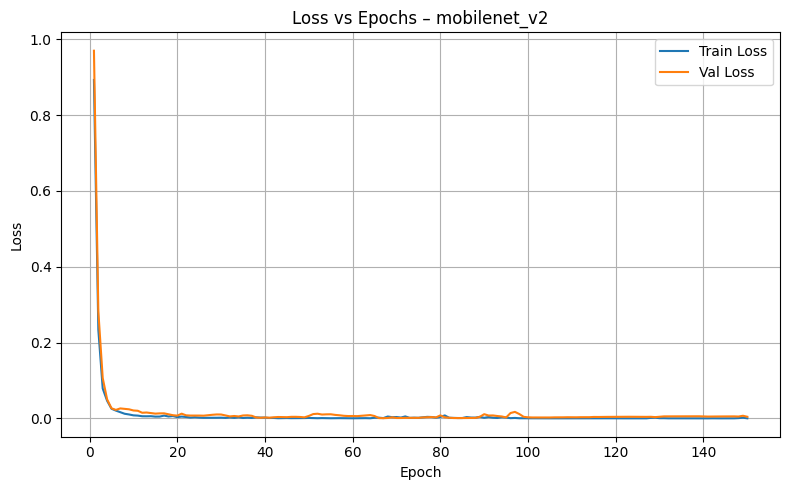

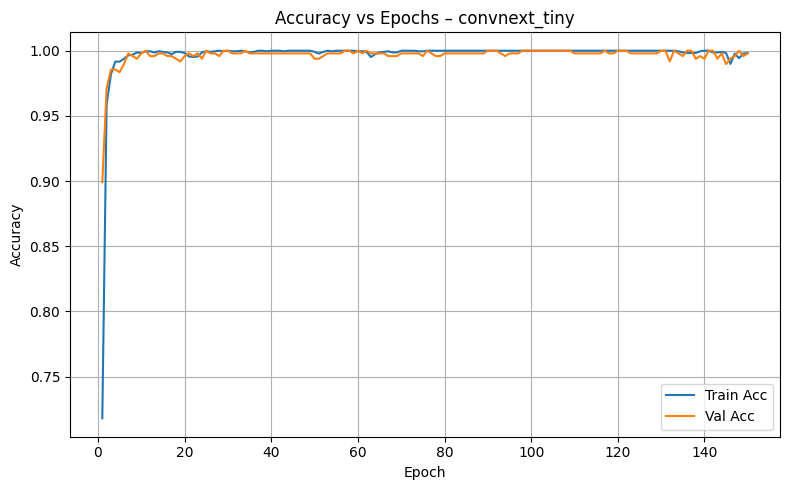

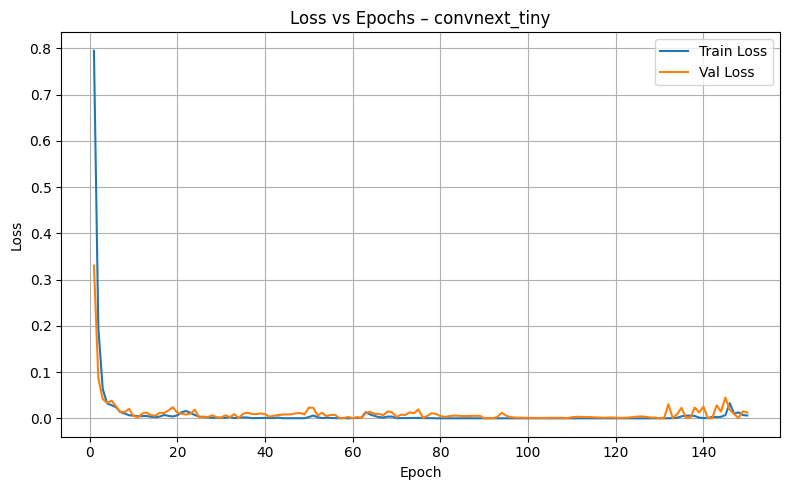

In [13]:
# Plot training/validation accuracy and loss for each backbone
epochs = range(1, NUM_EPOCHS + 1)

for model_name in MODEL_NAMES:
    h = histories[model_name]

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, h["train_acc"], label="Train Acc")
    plt.plot(epochs, h["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy vs Epochs – {model_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"figures/{model_name}_accuracy.png", dpi=150)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, h["train_loss"], label="Train Loss")
    plt.plot(epochs, h["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss vs Epochs – {model_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"figures/{model_name}_loss.png", dpi=150)
    plt.show()

## Visualizations – confusion matrices for CNN backbones

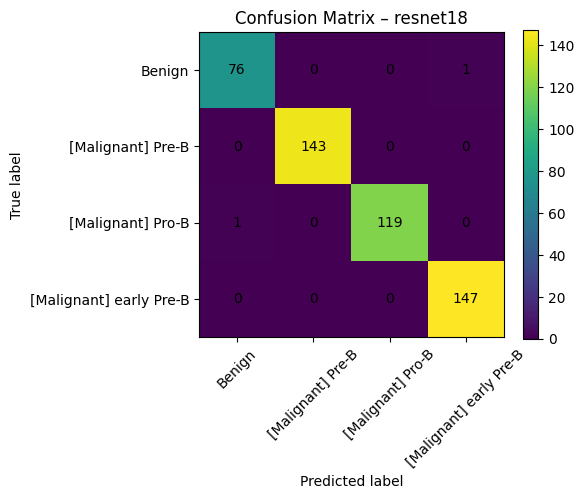

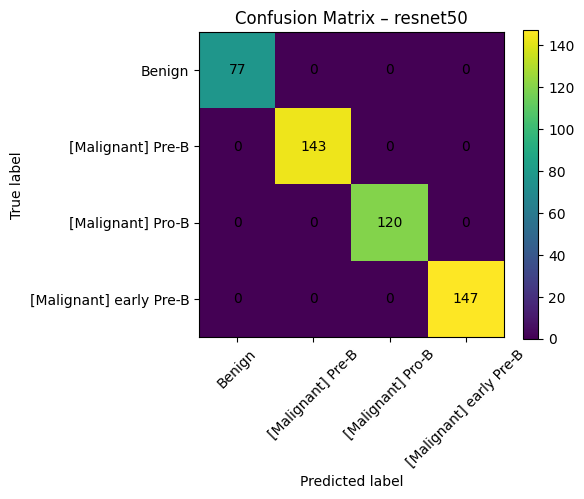

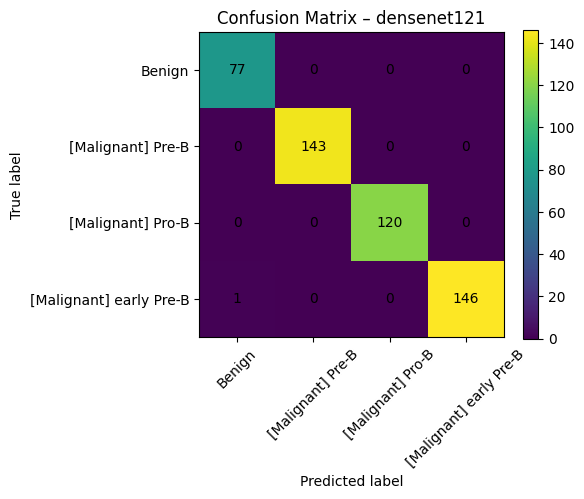

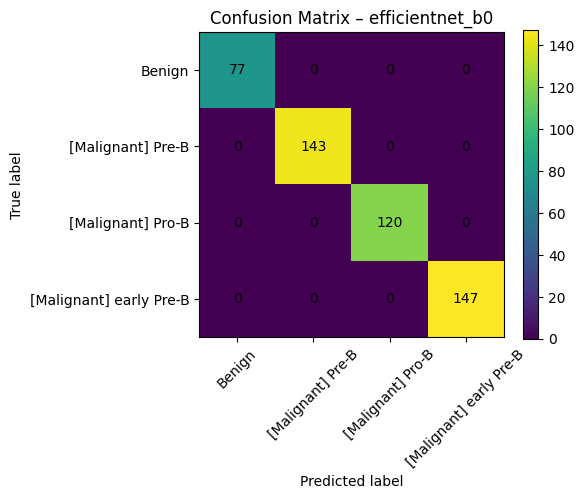

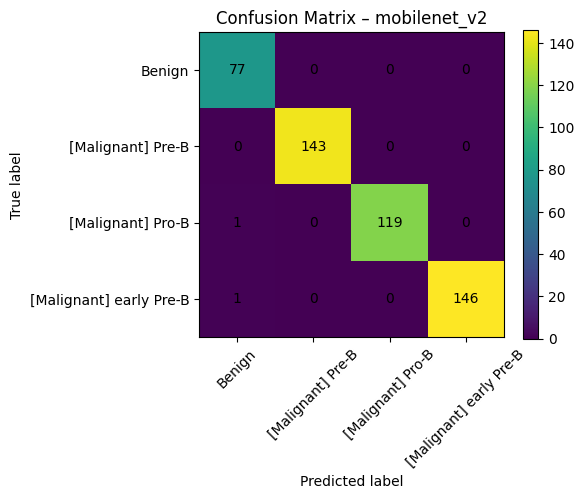

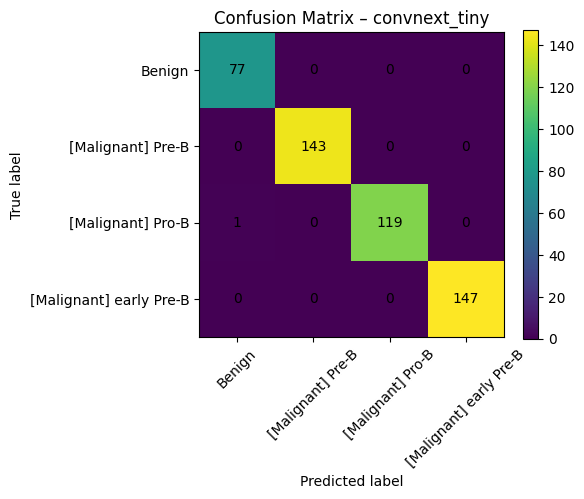

In [14]:
import itertools

def plot_confusion_matrix(cm, classes, title, filename):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 verticalalignment="center")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()


for model_name in MODEL_NAMES:
    cm = cms[model_name]
    plot_confusion_matrix(
        cm,
        class_names,
        title=f"Confusion Matrix – {model_name}",
        filename=f"figures/{model_name}_cm.png",
    )

## Step 2: RL-based CNN – augmentation bandit for each backbone

Now we treat each trained CNN as the **environment** and train a small RL policy network
that learns which augmentation policy to apply for each image.

This gives 6 RL-based CNN models:
- (ResNet18 + RL policy)
- (ResNet50 + RL policy)
- (DenseNet121 + RL policy)
- (EfficientNet-B0 + RL policy)
- (MobileNetV2 + RL policy)
- (ConvNeXt-Tiny + RL policy)


In [18]:
import torch.nn.functional as F

# Define augmentation actions for RL
aug_policies = [
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(25),
        transforms.ToTensor(),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.03),
        transforms.ToTensor(),
    ]),
]

NUM_ACTIONS = len(aug_policies)


class RLPolicyNet(nn.Module):
    def __init__(self, state_dim: int, num_actions: int):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, 256)
        self.fc2 = nn.Linear(256, num_actions)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        logits = self.fc2(x)
        return F.log_softmax(logits, dim=-1)


def build_frozen_backbone():
    # use ImageNet ResNet18 for state features
    base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    modules = list(base.children())[:-1]
    backbone = nn.Sequential(*modules)
    backbone.to(DEVICE)
    backbone.eval()
    for p in backbone.parameters():
        p.requires_grad = False
    return backbone, 512  # feature dim


class AugmentationBanditEnv:
    """
    Contextual bandit:
      - state: backbone features of original (non-augmented) image
      - action: choose one augmentation policy (0,1,2)
      - reward: 1 if classifier is correct on augmented image, else 0
    """
    def __init__(self, image_root, classifier_model, backbone, backbone_feat_dim):
        self.image_root = image_root
        self.classifier = classifier_model.to(DEVICE)
        self.classifier.eval()
        self.backbone = backbone
        self.backbone_feat_dim = backbone_feat_dim

        self.base_dataset = datasets.ImageFolder(
            root=str(image_root),
            transform=transforms.Resize((IMG_SIZE, IMG_SIZE)),
        )
        self.indices = list(range(len(self.base_dataset)))

    def sample_batch(self, batch_size: int):
        batch_indices = random.sample(self.indices, batch_size)
        imgs = []
        labels = []
        for idx in batch_indices:
            img, label = self.base_dataset[idx]
            imgs.append(img)
            labels.append(label)
        return imgs, torch.tensor(labels, dtype=torch.long)

    @torch.no_grad()
    def extract_state_features(self, imgs: List):
        """
        imgs: list of PIL Images (as returned by base_dataset).
        Apply preprocessing (resize, to-tensor, normalize) before passing
        through the frozen backbone to obtain features.
        """
        preprocess = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

        processed = [preprocess(img) for img in imgs]
        x = torch.stack(processed).to(DEVICE)
        with torch.cuda.amp.autocast(enabled=False):
            feats = self.backbone(x)
            feats = feats.view(feats.size(0), -1)
        return feats

    def step(self, policy_net: RLPolicyNet, batch_size: int = 128):
        """Single interaction step over a mini-batch."""
        imgs, labels = self.sample_batch(batch_size)
        labels = labels.to(DEVICE)

        state_feats = self.extract_state_features(imgs)
        log_probs_actions = policy_net(state_feats)  # (B, A)
        probs = log_probs_actions.exp()
        dist = torch.distributions.Categorical(probs=probs)
        actions = dist.sample()
        chosen_log_probs = dist.log_prob(actions)

        aug_imgs = []
        for img, a in zip(imgs, actions.cpu().tolist()):
            aug_img = aug_policies[a](img)
            aug_imgs.append(aug_img)
        aug_batch = torch.stack(aug_imgs).to(DEVICE)

        with torch.no_grad():
            outputs = self.classifier(aug_batch)
            preds = outputs.argmax(dim=1)
        rewards = (preds == labels).float()

        return chosen_log_probs, rewards


def train_rl_augmentation_bandit(
    clf_model,
    image_root,
    episodes: int = 10,
    batch_size: int = 128,
    lr: float = 1e-4,
):
    """Train a policy network for one CNN backbone."""
    backbone, state_dim = build_frozen_backbone()
    env = AugmentationBanditEnv(image_root, clf_model, backbone, state_dim)
    policy_net = RLPolicyNet(state_dim=state_dim, num_actions=NUM_ACTIONS).to(DEVICE)
    optimizer = optim.Adam(policy_net.parameters(), lr=lr)

    avg_rewards = []

    for episode in range(1, episodes + 1):
        policy_net.train()
        log_probs, rewards = env.step(policy_net, batch_size=batch_size)
        loss = -(log_probs * rewards.to(DEVICE)).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_reward = rewards.mean().item()
        avg_rewards.append(avg_reward)
        print(f"[RL] Episode {episode}/{episodes} | Loss: {loss.item():.4f} | Avg reward: {avg_reward:.4f}")

    return policy_net, avg_rewards


### Train RL policy for each CNN backbone

This will produce 6 RL-based CNN models and plots of the reward curves.
You can reduce `episodes` or `batch_size` if this is too heavy.


===== Training RL augmentation policy for resnet18 =====


/tmp/ipykernel_3866309/3249575654.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


[RL] Episode 1/10 | Loss: 0.3000 | Avg reward: 0.2891
[RL] Episode 2/10 | Loss: 0.2275 | Avg reward: 0.2266
[RL] Episode 2/10 | Loss: 0.2275 | Avg reward: 0.2266
[RL] Episode 3/10 | Loss: 0.1630 | Avg reward: 0.1875
[RL] Episode 3/10 | Loss: 0.1630 | Avg reward: 0.1875
[RL] Episode 4/10 | Loss: 0.2266 | Avg reward: 0.2109
[RL] Episode 4/10 | Loss: 0.2266 | Avg reward: 0.2109
[RL] Episode 5/10 | Loss: 0.2686 | Avg reward: 0.2891
[RL] Episode 5/10 | Loss: 0.2686 | Avg reward: 0.2891
[RL] Episode 6/10 | Loss: 0.1769 | Avg reward: 0.1875
[RL] Episode 6/10 | Loss: 0.1769 | Avg reward: 0.1875
[RL] Episode 7/10 | Loss: 0.2406 | Avg reward: 0.2344
[RL] Episode 7/10 | Loss: 0.2406 | Avg reward: 0.2344
[RL] Episode 8/10 | Loss: 0.1716 | Avg reward: 0.1875
[RL] Episode 8/10 | Loss: 0.1716 | Avg reward: 0.1875
[RL] Episode 9/10 | Loss: 0.1911 | Avg reward: 0.2031
[RL] Episode 9/10 | Loss: 0.1911 | Avg reward: 0.2031
[RL] Episode 10/10 | Loss: 0.1501 | Avg reward: 0.1641
[RL] Episode 10/10 | Loss: 

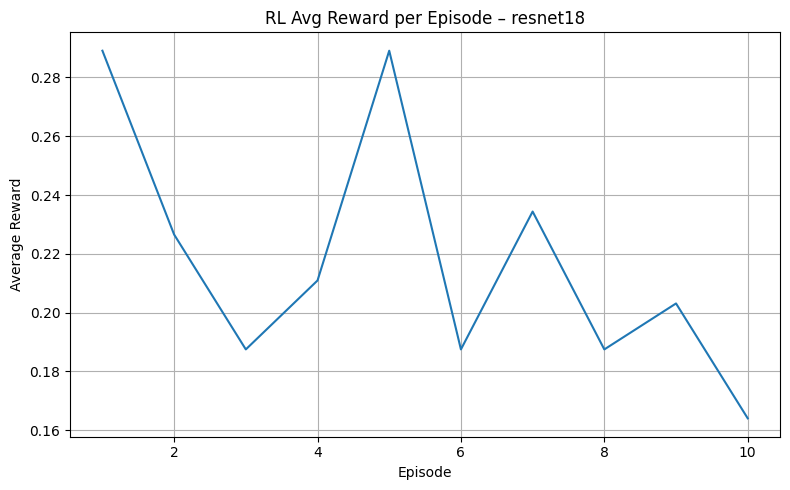


===== Training RL augmentation policy for resnet50 =====
[RL] Episode 1/10 | Loss: 0.4083 | Avg reward: 0.3672
[RL] Episode 1/10 | Loss: 0.4083 | Avg reward: 0.3672
[RL] Episode 2/10 | Loss: 0.3179 | Avg reward: 0.2969
[RL] Episode 2/10 | Loss: 0.3179 | Avg reward: 0.2969
[RL] Episode 3/10 | Loss: 0.3652 | Avg reward: 0.3359
[RL] Episode 3/10 | Loss: 0.3652 | Avg reward: 0.3359
[RL] Episode 4/10 | Loss: 0.3670 | Avg reward: 0.3359
[RL] Episode 4/10 | Loss: 0.3670 | Avg reward: 0.3359
[RL] Episode 5/10 | Loss: 0.3966 | Avg reward: 0.3594
[RL] Episode 5/10 | Loss: 0.3966 | Avg reward: 0.3594
[RL] Episode 6/10 | Loss: 0.3557 | Avg reward: 0.3281
[RL] Episode 6/10 | Loss: 0.3557 | Avg reward: 0.3281
[RL] Episode 7/10 | Loss: 0.4174 | Avg reward: 0.3906
[RL] Episode 7/10 | Loss: 0.4174 | Avg reward: 0.3906
[RL] Episode 8/10 | Loss: 0.3123 | Avg reward: 0.2891
[RL] Episode 8/10 | Loss: 0.3123 | Avg reward: 0.2891
[RL] Episode 9/10 | Loss: 0.4279 | Avg reward: 0.3984
[RL] Episode 9/10 | Loss

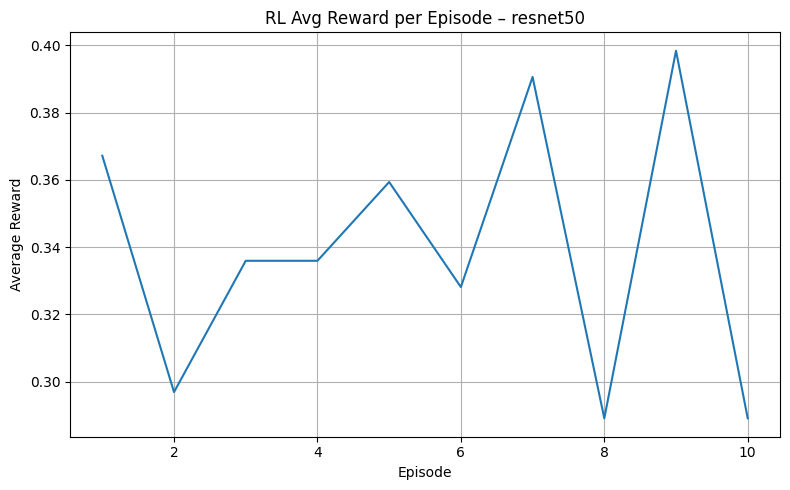


===== Training RL augmentation policy for densenet121 =====
[RL] Episode 1/10 | Loss: 0.5088 | Avg reward: 0.4688
[RL] Episode 1/10 | Loss: 0.5088 | Avg reward: 0.4688
[RL] Episode 2/10 | Loss: 0.5529 | Avg reward: 0.5078
[RL] Episode 2/10 | Loss: 0.5529 | Avg reward: 0.5078
[RL] Episode 3/10 | Loss: 0.5035 | Avg reward: 0.4688
[RL] Episode 3/10 | Loss: 0.5035 | Avg reward: 0.4688
[RL] Episode 4/10 | Loss: 0.5078 | Avg reward: 0.4922
[RL] Episode 4/10 | Loss: 0.5078 | Avg reward: 0.4922
[RL] Episode 5/10 | Loss: 0.5365 | Avg reward: 0.5234
[RL] Episode 5/10 | Loss: 0.5365 | Avg reward: 0.5234
[RL] Episode 6/10 | Loss: 0.4808 | Avg reward: 0.4922
[RL] Episode 6/10 | Loss: 0.4808 | Avg reward: 0.4922
[RL] Episode 7/10 | Loss: 0.5504 | Avg reward: 0.5156
[RL] Episode 7/10 | Loss: 0.5504 | Avg reward: 0.5156
[RL] Episode 8/10 | Loss: 0.5725 | Avg reward: 0.5859
[RL] Episode 8/10 | Loss: 0.5725 | Avg reward: 0.5859
[RL] Episode 9/10 | Loss: 0.4780 | Avg reward: 0.5078
[RL] Episode 9/10 | L

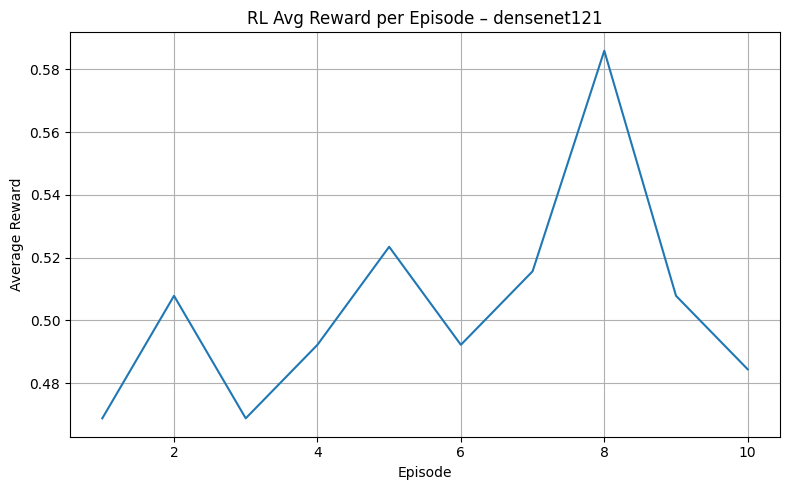


===== Training RL augmentation policy for efficientnet_b0 =====
[RL] Episode 1/10 | Loss: 0.4339 | Avg reward: 0.4219
[RL] Episode 1/10 | Loss: 0.4339 | Avg reward: 0.4219
[RL] Episode 2/10 | Loss: 0.5279 | Avg reward: 0.4766
[RL] Episode 2/10 | Loss: 0.5279 | Avg reward: 0.4766
[RL] Episode 3/10 | Loss: 0.6213 | Avg reward: 0.5391
[RL] Episode 3/10 | Loss: 0.6213 | Avg reward: 0.5391
[RL] Episode 4/10 | Loss: 0.4766 | Avg reward: 0.4453
[RL] Episode 4/10 | Loss: 0.4766 | Avg reward: 0.4453
[RL] Episode 5/10 | Loss: 0.4240 | Avg reward: 0.3750
[RL] Episode 5/10 | Loss: 0.4240 | Avg reward: 0.3750
[RL] Episode 6/10 | Loss: 0.5701 | Avg reward: 0.5312
[RL] Episode 6/10 | Loss: 0.5701 | Avg reward: 0.5312
[RL] Episode 7/10 | Loss: 0.5450 | Avg reward: 0.4922
[RL] Episode 7/10 | Loss: 0.5450 | Avg reward: 0.4922
[RL] Episode 8/10 | Loss: 0.4737 | Avg reward: 0.4453
[RL] Episode 8/10 | Loss: 0.4737 | Avg reward: 0.4453
[RL] Episode 9/10 | Loss: 0.4719 | Avg reward: 0.4297
[RL] Episode 9/10

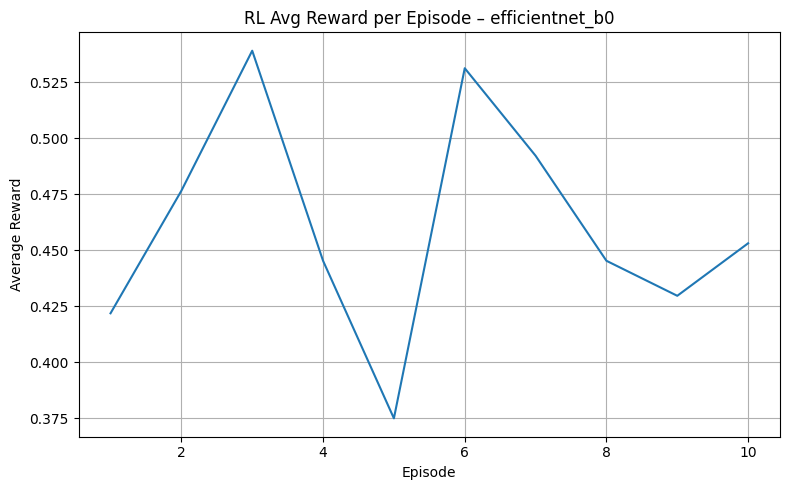


===== Training RL augmentation policy for mobilenet_v2 =====
[RL] Episode 1/10 | Loss: 0.4944 | Avg reward: 0.4531
[RL] Episode 1/10 | Loss: 0.4944 | Avg reward: 0.4531
[RL] Episode 2/10 | Loss: 0.4310 | Avg reward: 0.3750
[RL] Episode 2/10 | Loss: 0.4310 | Avg reward: 0.3750
[RL] Episode 3/10 | Loss: 0.3848 | Avg reward: 0.3438
[RL] Episode 3/10 | Loss: 0.3848 | Avg reward: 0.3438
[RL] Episode 4/10 | Loss: 0.4721 | Avg reward: 0.4297
[RL] Episode 4/10 | Loss: 0.4721 | Avg reward: 0.4297
[RL] Episode 5/10 | Loss: 0.3784 | Avg reward: 0.3438
[RL] Episode 5/10 | Loss: 0.3784 | Avg reward: 0.3438
[RL] Episode 6/10 | Loss: 0.4729 | Avg reward: 0.4297
[RL] Episode 6/10 | Loss: 0.4729 | Avg reward: 0.4297
[RL] Episode 7/10 | Loss: 0.4951 | Avg reward: 0.4531
[RL] Episode 7/10 | Loss: 0.4951 | Avg reward: 0.4531
[RL] Episode 8/10 | Loss: 0.4630 | Avg reward: 0.4219
[RL] Episode 8/10 | Loss: 0.4630 | Avg reward: 0.4219
[RL] Episode 9/10 | Loss: 0.4474 | Avg reward: 0.4219
[RL] Episode 9/10 | 

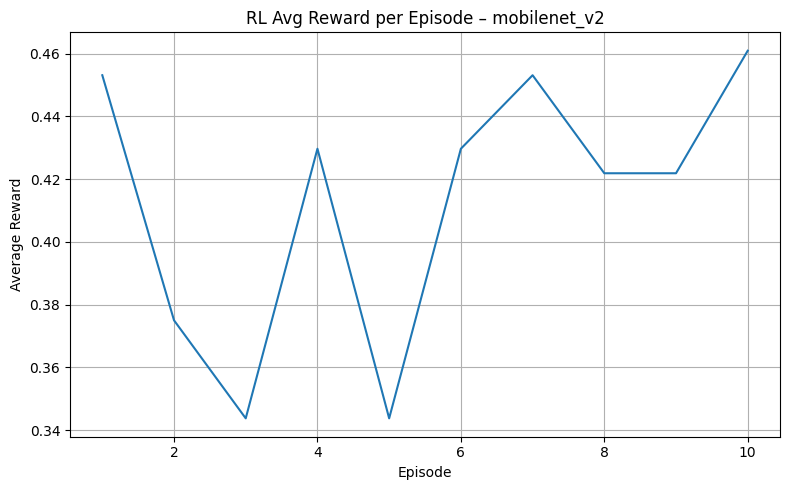


===== Training RL augmentation policy for convnext_tiny =====
[RL] Episode 1/10 | Loss: 0.5518 | Avg reward: 0.5234
[RL] Episode 1/10 | Loss: 0.5518 | Avg reward: 0.5234
[RL] Episode 2/10 | Loss: 0.6121 | Avg reward: 0.5625
[RL] Episode 2/10 | Loss: 0.6121 | Avg reward: 0.5625
[RL] Episode 3/10 | Loss: 0.6121 | Avg reward: 0.5781
[RL] Episode 3/10 | Loss: 0.6121 | Avg reward: 0.5781
[RL] Episode 4/10 | Loss: 0.6537 | Avg reward: 0.6094
[RL] Episode 4/10 | Loss: 0.6537 | Avg reward: 0.6094
[RL] Episode 5/10 | Loss: 0.6562 | Avg reward: 0.6016
[RL] Episode 5/10 | Loss: 0.6562 | Avg reward: 0.6016
[RL] Episode 6/10 | Loss: 0.6656 | Avg reward: 0.6328
[RL] Episode 6/10 | Loss: 0.6656 | Avg reward: 0.6328
[RL] Episode 7/10 | Loss: 0.5149 | Avg reward: 0.4922
[RL] Episode 7/10 | Loss: 0.5149 | Avg reward: 0.4922
[RL] Episode 8/10 | Loss: 0.6703 | Avg reward: 0.6250
[RL] Episode 8/10 | Loss: 0.6703 | Avg reward: 0.6250
[RL] Episode 9/10 | Loss: 0.6124 | Avg reward: 0.5938
[RL] Episode 9/10 |

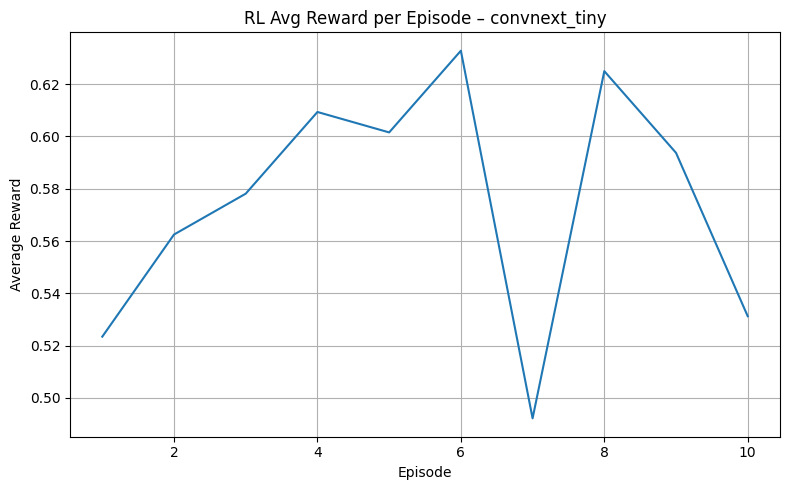

All RL policies trained. Each CNN + its RL policy constitutes an RL-based CNN model.


In [19]:
rl_policies: Dict[str, RLPolicyNet] = {}
rl_histories: Dict[str, List[float]] = {}

EPISODES_RL = 10
BATCH_SIZE_RL = 128

for model_name in MODEL_NAMES:
    print(f"\n===== Training RL augmentation policy for {model_name} =====")
    clf = trained_models[model_name]
    policy_net, avg_rewards = train_rl_augmentation_bandit(
        clf_model=clf,
        image_root=image_root,
        episodes=EPISODES_RL,
        batch_size=BATCH_SIZE_RL,
        lr=1e-4,
    )
    rl_policies[model_name] = policy_net
    rl_histories[model_name] = avg_rewards

    # Save RL policy weights
    torch.save(policy_net.state_dict(), f"rl_policies/{model_name}_rl_policy.pth")

    # Plot reward curve
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(avg_rewards) + 1), avg_rewards)
    plt.xlabel("Episode")
    plt.ylabel("Average Reward")
    plt.title(f"RL Avg Reward per Episode – {model_name}")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"figures/{model_name}_rl_reward.png", dpi=150)
    plt.show()

print("All RL policies trained. Each CNN + its RL policy constitutes an RL-based CNN model.")